# Dataset Collection and Understanding

#### Import Required Libraries

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Load Dataset

In [85]:
df = pd.read_csv("Downloads/online_retail.csv")

#### View Data

In [86]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


#### DataSet Information

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


#### DataSet Description

In [88]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


#### View Shape

In [89]:
df.shape

(541909, 8)

#### Check Column Names

In [90]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

#### Check Data Types

In [91]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

#### Check Missing Values

In [92]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

#### Check Duplicate Rows

In [93]:
df.duplicated().sum()

np.int64(5268)

#### Check Unique Customers

In [94]:
df["CustomerID"].nunique()


4372

#### Check Unique Products

In [95]:
df["Description"].nunique()

4223

#### Check Countries

In [96]:
df["Country"].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

#### Check Date Range

In [97]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [98]:
print(df["InvoiceDate"].min())
print(df["InvoiceDate"].max())

2022-12-01 08:26:00
2023-12-09 12:50:00


# Data Preprocessing (Cleaning)

#### Remove Missing CustomerID

In [99]:
df = df.dropna(subset=["CustomerID"])

#### Remove Cancelled Invoices

In [100]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

#### Remove Negative or Zero Quantities

In [101]:
df = df[df['Quantity'] > 0]

#### Remove Zero or Negative UnitPrice

In [102]:
df = df[df['UnitPrice'] > 0]

#### Convert CustomerID to Integer

In [103]:
df["CustomerID"] = df["CustomerID"].astype(int)

#### Convert InvoiceDate to Datetime

In [104]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

#### Create Total Amount Column

In [105]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [106]:
# Shape after Cleaning
df.shape

(397884, 9)

# Exploratory Data Analysis

### Transaction Volume by Country

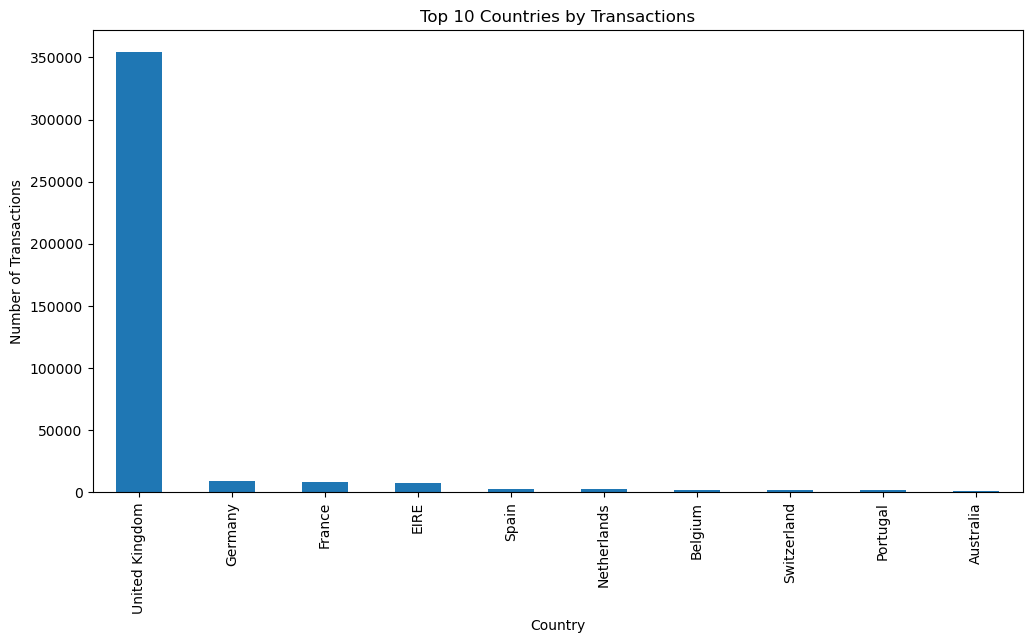

In [107]:
country_transactions = df["Country"].value_counts()
plt.figure(figsize=(12,6))
country_transactions.head(10).plot(kind='bar')  
plt.title("Top 10 Countries by Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.show()

The transaction volume analysis shows that a few countries contribute the majority of orders. This indicates that the business has a strong customer base in specific regions. High-transaction countries should be prioritized for marketing campaigns, inventory planning, and customer retention strategies.

### Top Selling Products

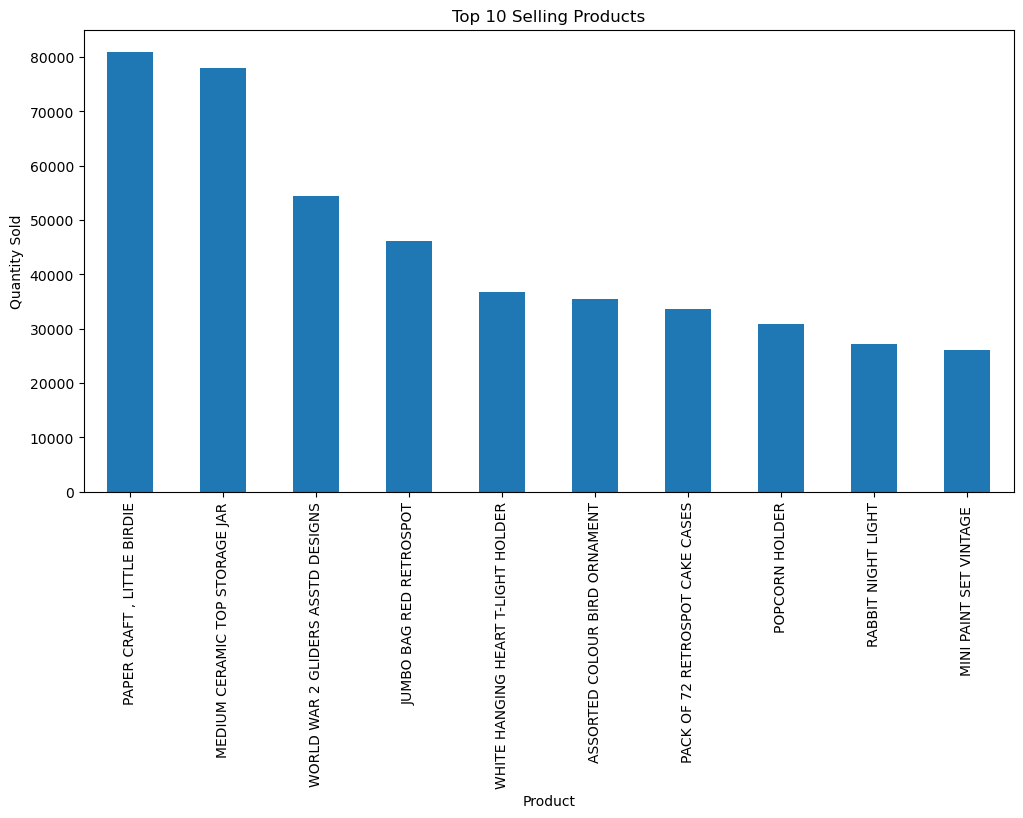

In [108]:
top_products = df.groupby('Description')['Quantity'].sum()

top_products = top_products.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))
top_products.plot(kind='bar')

plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.show()

A small number of products account for a significant portion of sales volume. These products are highly preferred by customers and represent the core demand drivers of the business.

### Monthly Sales Trend

In [109]:
# Create Month Column¶
df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [110]:
# Calculate Monthly Sales
monthly_sales = df.groupby("Month")["TotalAmount"].sum()

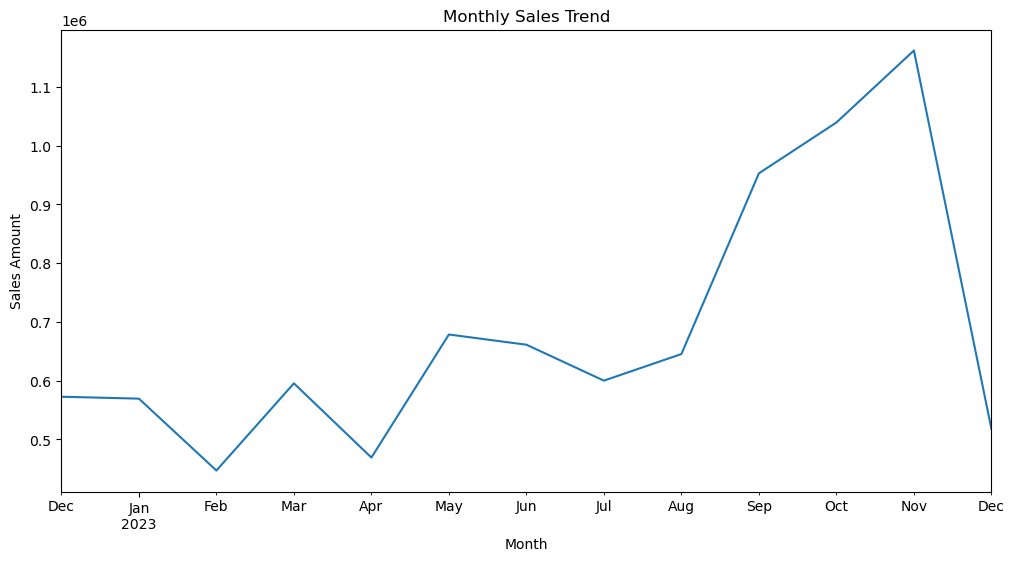

In [111]:
# Plot
plt.figure(figsize=(12,6))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.show()

Sales fluctuate over time, indicating seasonal purchasing behavior. Certain months generate significantly higher revenue compared to others.

### Quantity Distribution

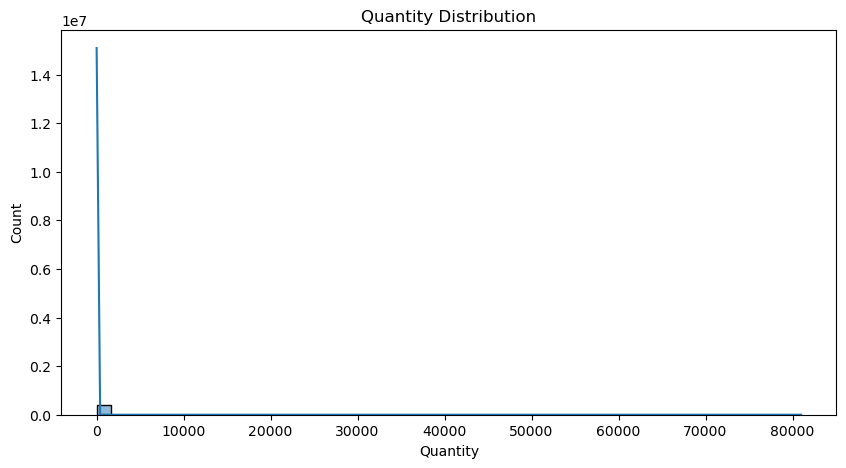

In [112]:
plt.figure(figsize=(10,5))
sns.histplot(
    df["Quantity"],
    bins=50,
    kde=True
)

plt.title("Quantity Distribution")
plt.show()

The quantity distribution is highly right-skewed. Most transactions contain small purchase quantities, while a few transactions involve very large bulk purchases.

### Total Amount Distribution

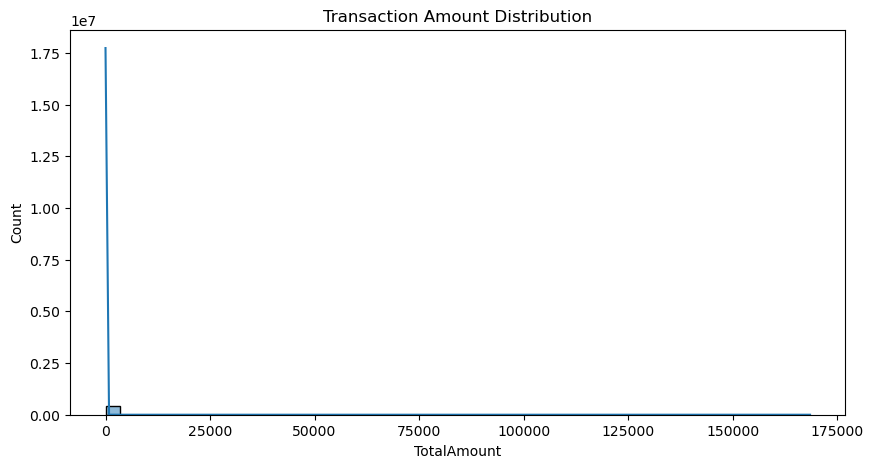

In [113]:
plt.figure(figsize=(10,5))
sns.histplot(
    df["TotalAmount"],
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution")
plt.show()

Most transactions have relatively low monetary value, while a small number of transactions contribute very high revenue.

### Top Revenue Countries

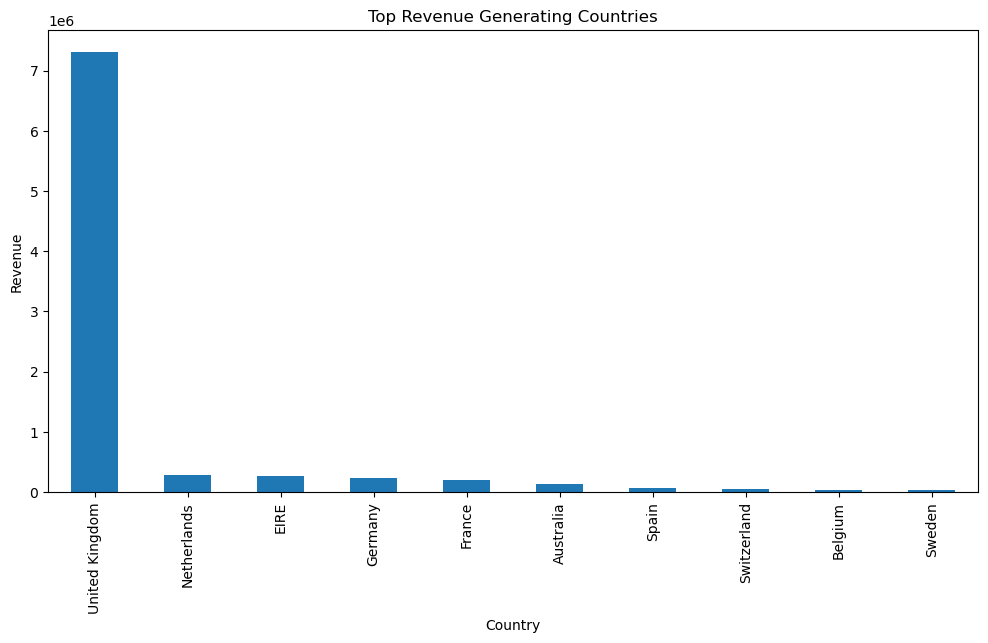

In [114]:
country_revenue = df.groupby(
    'Country'
)["TotalAmount"].sum()

country_revenue = country_revenue.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

country_revenue.plot(kind='bar')

plt.title("Top Revenue Generating Countries")
plt.ylabel("Revenue")

plt.show()

Some countries generate significantly higher revenue despite having fewer transactions, indicating higher customer spending power.

### Correlation Analysis

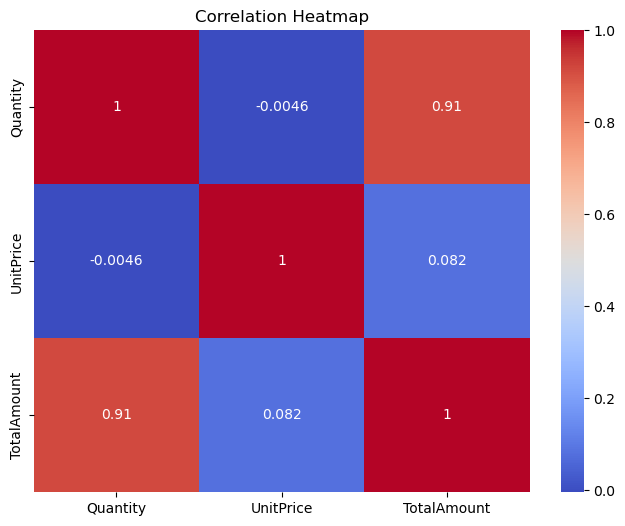

In [115]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[["Quantity",
        "UnitPrice",
        "TotalAmount"]]
    .corr(),
    annot=True,
    cmap="coolwarm"
    
)

plt.title("Correlation Heatmap")
plt.show()


A strong positive relationship exists between Quantity purchased and Total Amount spent. Customers buying more products generally spend more money.

### Boxplot for Outliers

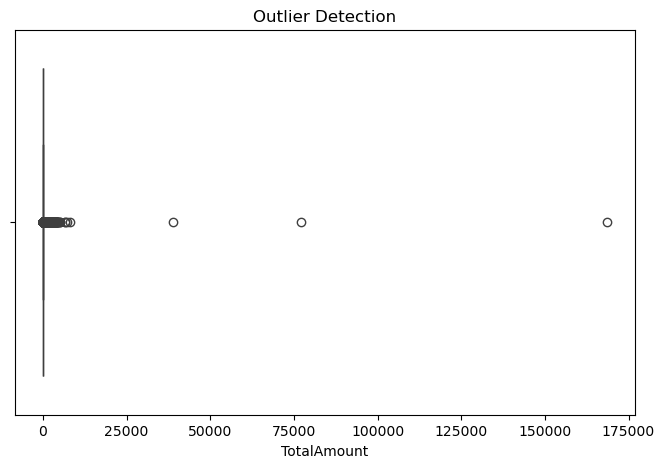

In [116]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x=df["TotalAmount"]
)
plt.title("Outlier Detection")
plt.show()

The dataset contains several extreme transactions with unusually high purchase quantities or spending values.

### Top Customers by Spending

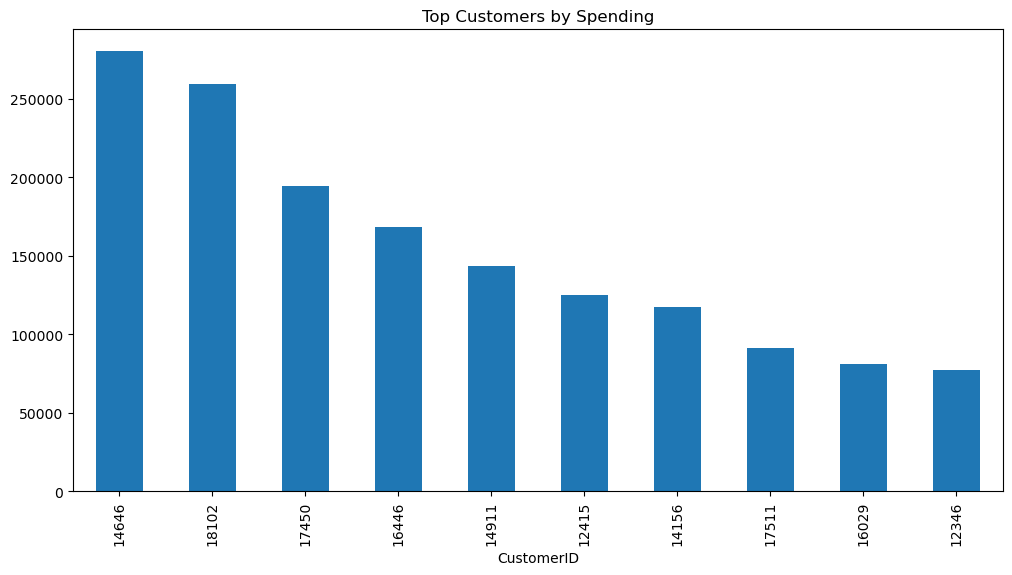

In [117]:
top_customers = df.groupby(
    "CustomerID"
)["TotalAmount"].sum()

top_customers = top_customers.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))
top_customers.plot(kind='bar')
plt.title("Top Customers by Spending")
plt.show()

A small group of customers contributes a large share of total revenue. These customers are highly valuable to the business.

### Country Distribution Pie Chart

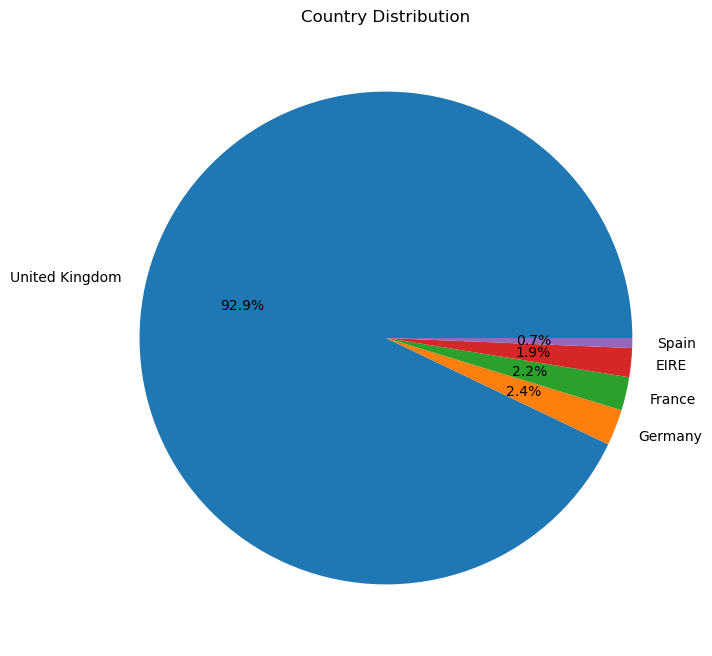

In [118]:
country_count = df['Country'].value_counts().head(5)

plt.figure(figsize=(8,8))

plt.pie(
    country_count,
    labels=country_count.index,
    autopct='%1.1f%%'
)

plt.title("Country Distribution")

plt.show()

Customer distribution is not uniform across countries. Some countries dominate the customer base while others have relatively low participation.

# Clustering Methodology (RFM Feature Engineering + K-Means Clustering)

### Find Reference Date

In [119]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

### Create RFM Features

In [120]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

In [121]:
# Rename Columns
rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

In [122]:
# View RFM Table
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


### Check RFM Distribution

In [123]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


##### Recency:-  Recency measures how recently a customer made a purchase. Customers with low recency values have purchased recently and are more likely to engage with future promotions. Customers with high recency values have not purchased for a long time and may be at risk of churn.

##### Frequency:- Frequency indicates how often a customer purchases. Customers with high frequency values demonstrate strong loyalty and repeated engagement with the business.

##### Monetary:- Monetary value measures the total amount spent by each customer. A small percentage of customers often contributes a large portion of total revenue.

### Standardization

In [124]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

In [125]:
# Create Scaler
scaler = StandardScaler()

In [126]:
# Fit and Transform
rfm_scaled = scaler.fit_transform(rfm)

In [127]:
# Convert to DataFrame
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)

In [128]:
# Save Scaler
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler Saved Successfully")

Scaler Saved Successfully


##### Recency, Frequency, and Monetary values exist on different scales. Standardization ensures that no single feature dominates the clustering process.

### Elbow Method

In [129]:
# Import KMeans
from sklearn.cluster import KMeans

In [130]:
# Create Empty List
inertia_values = []

In [131]:
for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(rfm_scaled)

    inertia_values.append(
        kmeans.inertia_
    )
    


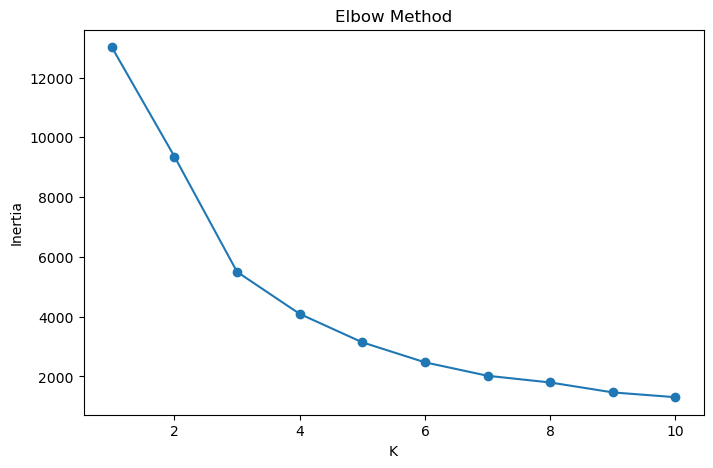

In [132]:
# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(
    range(1,11),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

##### The Elbow Method helps determine the optimal number of customer segments. The selected K value balances cluster quality and business interpretability.

##### The elbow point was observed at K = 4, indicating that four customer segments provide the best balance between simplicity and cluster quality.

### Silhouette Score

In [133]:
# Silhouette Score
from sklearn.metrics import silhouette_score

In [134]:
# Calculate
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(
    rfm_scaled
)

In [135]:
score = silhouette_score(
    rfm_scaled,
    clusters
)

print(score)

0.616212846765192


##### Silhouette Score evaluates how well customers fit within their assigned clusters and how distinct the clusters are from one another A high silhouette score indicates that customers within each cluster share similar purchasing behavior while remaining distinct from other clusters.

### Final KMeans

In [136]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm["Cluster"] = kmeans.fit_predict(
    rfm_scaled
)

##### K-Means clustering successfully divided customers into groups with different purchasing patterns.

### View Cluster Centroids

In [137]:
kmeans.cluster_centers_

array([[-0.48832448, -0.07656166, -0.07734781],
       [ 1.55535385, -0.35337933, -0.17507955],
       [-0.85149559, 10.16828936, 13.9387338 ],
       [-0.77034388,  2.34650634,  1.18542431]])

### Cluster Summary

In [138]:
cluster_summary = rfm.groupby(
    "Cluster"
)[
    ["Recency",
     "Frequency",
     "Monetary"]
].mean()

print(cluster_summary)

            Recency  Frequency       Monetary
Cluster                                      
0         43.702685   3.682711    1359.049284
1        248.075914   1.552015     480.617480
2          7.384615  82.538462  127338.313846
3         15.500000  22.333333   12709.090490


### Label Clusters

In [139]:
cluster_names = {
    0:"High Value",
    1:"Regular",
    2:"Occasional",
    3:"At Risk"
}

rfm["Segment"] = rfm[
    "Cluster"
].map(cluster_names)

### Visualize Clusters

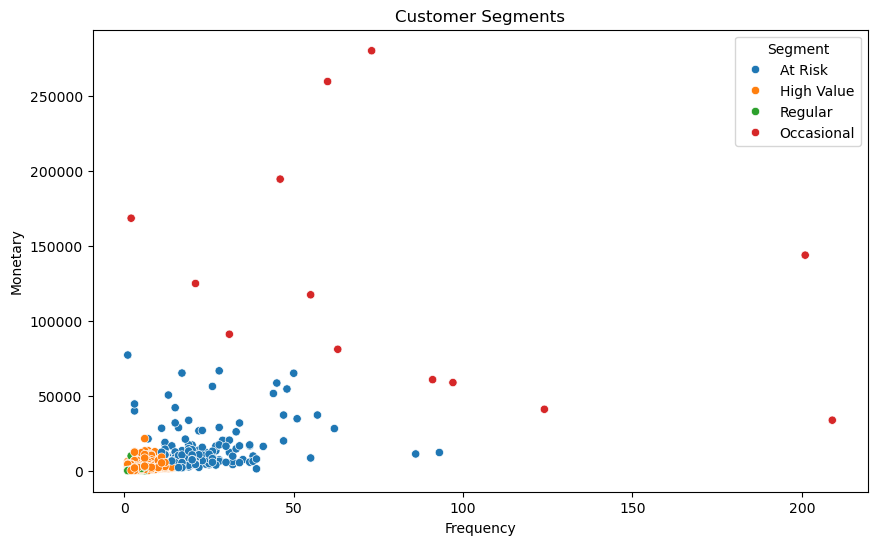

In [140]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Segment"
)

plt.title("Customer Segments")
plt.show()

### Save Model

In [141]:
import joblib
joblib.dump(
    kmeans,
    "customer_segmentation.pkl"
)

['customer_segmentation.pkl']

# Product Recommendation System

### Create Customer-Product Matrix

In [142]:
customer_product_matrix = df.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

### Transpose Matrix

In [143]:
product_matrix = customer_product_matrix.T

### Import Cosine Similarity

In [144]:
# To calculate similarity between vectors
from sklearn.metrics.pairwise import cosine_similarity

### Calculate Similarity Matrix

In [145]:
similarity_matrix = cosine_similarity(
    product_matrix
)

### Convert Similarity Matrix to DataFrame

In [146]:
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=product_matrix.index,
    columns=product_matrix.index
)

### Recommendation Function

In [147]:
def recommend_products(
    product_name,
    top_n=5):

    similar_products = similarity_df[
        product_name
    ]
    recommendations = similar_products\
        .sort_values(
            ascending=False
        )
    recommendations = recommendations[
        1:top_n+1
    ]

    return recommendations.index.tolist()

### Test Recommendation System

In [148]:
recommend_products(
    "WHITE HANGING HEART T-LIGHT HOLDER"
)

['GIN + TONIC DIET METAL SIGN',
 'RED HANGING HEART T-LIGHT HOLDER',
 'WASHROOM METAL SIGN',
 'LAUNDRY 15C METAL SIGN',
 'GREEN VINTAGE SPOT BEAKER']

### Similarity Heatmap

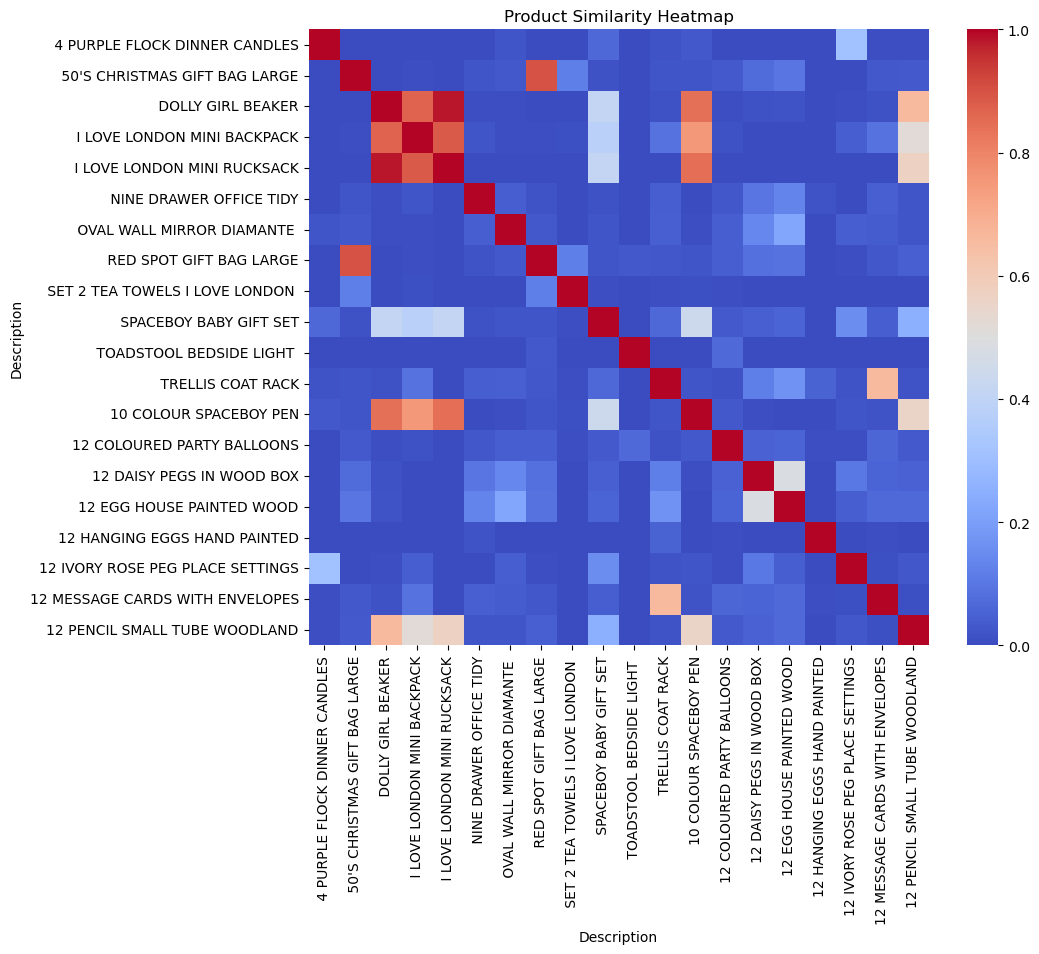

In [149]:
plt.figure(figsize=(10,8))

sns.heatmap(
    similarity_df.iloc[:20,:20],
    cmap="coolwarm"
)

plt.title(
    "Product Similarity Heatmap"
)

plt.show()

### Save Recommendation Model

In [150]:
import joblib

joblib.dump(
    similarity_df,
    "product_similarity.pkl"
)

['product_similarity.pkl']

# Streamlit Web Application Deployment

In this step, a web application was developed using Streamlit to make the machine learning models easy to use. The trained Customer Segmentation model, Product Recommendation model, and Scaler were loaded into the application using saved .pkl files.

The application contains two main modules:

#### Customer Segmentation Module
Users enter Recency, Frequency, and Monetary (RFM) values.
The application processes the input and predicts the customer segment.
Customers are classified into four groups:
High Value
Regular
Occasional
At Risk
#### Product Recommendation Module
Users enter a product name.
The application finds similar products using the product similarity matrix.
It recommends the top 5 related products based on customer purchasing behavior.

The Streamlit application provides a simple and interactive interface that allows users to get predictions and recommendations without writing any code. This makes the solution practical and user-friendly for business use.

#### Benefit
Helps businesses identify valuable customers.
Supports personalized marketing strategies.
Improves customer retention.
Increases sales through product recommendations.
Provides real-time predictions through an easy-to-use dashboard.